<a href="https://colab.research.google.com/github/juberijuber/Gender-and-Age-Prediction/blob/main/Gender_and_Age_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Choose Mode:
1 - Upload Image
2 - Use Webcam
Enter choice (1/2): 1
Upload an image:


Saving girl2.jpg to girl2.jpg
Gender: Female, Age: 8-12 years


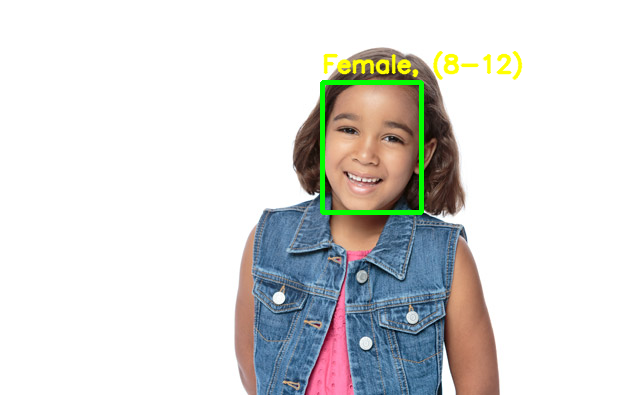

In [1]:
# # Install OpenCV
!pip install opencv-python opencv-python-headless

import cv2
import numpy as np
from google.colab import files

# ---------------------- DOWNLOAD MODELS ----------------------
# !wget -q https://raw.githubusercontent.com/spmallick/learnopencv/master/AgeGender/opencv_face_detector.pbtxt
# !wget -q https://raw.githubusercontent.com/spmallick/learnopencv/master/AgeGender/opencv_face_detector_uint8.pb
# !wget -q https://raw.githubusercontent.com/spmallick/learnopencv/master/AgeGender/age_deploy.prototxt
# !wget -q https://raw.githubusercontent.com/spmallick/learnopencv/master/AgeGender/age_net.caffemodel
# !wget -q https://raw.githubusercontent.com/spmallick/learnopencv/master/AgeGender/gender_deploy.prototxt
# !wget -q https://raw.githubusercontent.com/spmallick/learnopencv/master/AgeGender/gender_net.caffemodel

# ---------------------- LOAD MODELS ----------------------
faceNet = cv2.dnn.readNet("/content/drive/MyDrive/Gender and Age Prediction Models/opencv_face_detector_uint8.pb", "/content/drive/MyDrive/Gender and Age Prediction Models/opencv_face_detector.pbtxt")
ageNet = cv2.dnn.readNet("/content/drive/MyDrive/Gender and Age Prediction Models/age_net.caffemodel", "/content/drive/MyDrive/Gender and Age Prediction Models/age_deploy.prototxt")
genderNet = cv2.dnn.readNet("/content/drive/MyDrive/Gender and Age Prediction Models/gender_net.caffemodel", "/content/drive/MyDrive/Gender and Age Prediction Models/gender_deploy.prototxt")

MODEL_MEAN_VALUES = (78.4263377603, 87.7689143744, 114.895847746)
ageList = ['(0-2)', '(4-6)', '(8-12)', '(15-20)', '(25-32)', '(38-43)', '(48-53)', '(60-100)']
genderList = ['Male','Female']

# ---------------------- FACE DETECTION FUNCTION ----------------------
def highlightFace(net, frame, conf_threshold=0.7):
    frameOpencvDnn = frame.copy()
    frameHeight = frameOpencvDnn.shape[0]
    frameWidth = frameOpencvDnn.shape[1]
    blob = cv2.dnn.blobFromImage(frameOpencvDnn, 1.0, (300, 300),
                                 [104, 117, 123], True, False)
    net.setInput(blob)
    detections = net.forward()
    faceBoxes = []
    for i in range(detections.shape[2]):
        confidence = detections[0,0,i,2]
        if confidence > conf_threshold:
            x1 = int(detections[0,0,i,3] * frameWidth)
            y1 = int(detections[0,0,i,4] * frameHeight)
            x2 = int(detections[0,0,i,5] * frameWidth)
            y2 = int(detections[0,0,i,6] * frameHeight)
            faceBoxes.append([x1,y1,x2,y2])
            cv2.rectangle(frameOpencvDnn, (x1,y1), (x2,y2), (0,255,0),
                          int(round(frameHeight/150)), 8)
    return frameOpencvDnn, faceBoxes

# ---------------------- IMAGE UPLOAD VERSION ----------------------
def detect_from_image():
    print("Upload an image:")
    uploaded = files.upload()
    for filename in uploaded.keys():
        image = cv2.imread(filename)
        resultImg, faceBoxes = highlightFace(faceNet, image)
        if not faceBoxes:
            print("No face detected")
        for faceBox in faceBoxes:
            face = image[max(0,faceBox[1]-20):min(faceBox[3]+20, image.shape[0]-1),
                         max(0,faceBox[0]-20):min(faceBox[2]+20, image.shape[1]-1)]
            blob = cv2.dnn.blobFromImage(face, 1.0, (227,227), MODEL_MEAN_VALUES, swapRB=False)

            genderNet.setInput(blob)
            genderPreds = genderNet.forward()
            gender = genderList[genderPreds[0].argmax()]

            ageNet.setInput(blob)
            agePreds = ageNet.forward()
            age = ageList[agePreds[0].argmax()]

            print(f"Gender: {gender}, Age: {age[1:-1]} years")
            cv2.putText(resultImg, f"{gender}, {age}", (faceBox[0], faceBox[1]-10),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0,255,255), 2, cv2.LINE_AA)

        from google.colab.patches import cv2_imshow
        cv2_imshow(resultImg)

# ---------------------- WEBCAM VERSION ----------------------
def detect_from_webcam():
    from IPython.display import display, Javascript
    from google.colab.output import eval_js
    from base64 import b64decode, b64encode
    import io
    from PIL import Image

    def js_to_image(js_reply):
        image_bytes = b64decode(js_reply.split(',')[1])
        img = Image.open(io.BytesIO(image_bytes))
        return cv2.cvtColor(np.array(img), cv2.COLOR_RGB2BGR)

    def video_stream():
        js = Javascript('''
            async function takePhoto() {
                const div = document.createElement('div');
                document.body.appendChild(div);
                const video = document.createElement('video');
                div.appendChild(video);
                const stream = await navigator.mediaDevices.getUserMedia({video: true});
                video.srcObject = stream;
                await video.play();

                const canvas = document.createElement('canvas');
                canvas.width = video.videoWidth;
                canvas.height = video.videoHeight;
                const context = canvas.getContext('2d');
                context.drawImage(video, 0, 0);
                stream.getTracks().forEach(track => track.stop());
                return canvas.toDataURL('image/jpeg', 0.8);
            }
            takePhoto();
        ''')
        display(js)
        data = eval_js('takePhoto()')
        return data

    print("📷 Taking photo from webcam...")
    js_reply = video_stream()
    frame = js_to_image(js_reply)

    resultImg, faceBoxes = highlightFace(faceNet, frame)
    if not faceBoxes:
        print("No face detected")
    for faceBox in faceBoxes:
        face = frame[max(0,faceBox[1]-20):min(faceBox[3]+20, frame.shape[0]-1),
                     max(0,faceBox[0]-20):min(faceBox[2]+20, frame.shape[1]-1)]
        blob = cv2.dnn.blobFromImage(face, 1.0, (227,227), MODEL_MEAN_VALUES, swapRB=False)

        genderNet.setInput(blob)
        genderPreds = genderNet.forward()
        gender = genderList[genderPreds[0].argmax()]

        ageNet.setInput(blob)
        agePreds = ageNet.forward()
        age = ageList[agePreds[0].argmax()]

        print(f"Gender: {gender}, Age: {age[1:-1]} years")
        cv2.putText(resultImg, f"{gender}, {age}", (faceBox[0], faceBox[1]-10),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0,255,255), 2, cv2.LINE_AA)

    from google.colab.patches import cv2_imshow
    cv2_imshow(resultImg)

# ---------------------- RUN ----------------------
print("Choose Mode:\n1 - Upload Image\n2 - Use Webcam")
mode = input("Enter choice (1/2): ").strip()

if mode == "1":
    detect_from_image()
elif mode == "2":
    detect_from_webcam()
else:
    print("Invalid choice!")